In [3]:
# Importing required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = 'path_to_your_file/Housing.csv'  # replace with your file path
housing_data = pd.read_csv(r'E:\Housing.csv')  # Correct way to specify file path

# Display the first few rows of the dataset
housing_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
# Check for missing values
missing_data = housing_data.isnull().sum()
print(missing_data)

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [5]:
# List of numerical columns to scale
numerical_columns = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

# Standardization (z-score) to scale the features
scaler = StandardScaler()
housing_data[numerical_columns] = scaler.fit_transform(housing_data[numerical_columns])

# Check the scaled data
housing_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,1.046726,1.403419,1.421812,1.378217,yes,no,no,no,yes,1.517692,yes,furnished
1,12250000,1.757010,1.403419,5.405809,2.532024,yes,no,no,no,yes,2.679409,no,furnished
2,12250000,2.218232,0.047278,1.421812,0.224410,yes,no,yes,no,no,1.517692,yes,semi-furnished
3,12215000,1.083624,1.403419,1.421812,0.224410,yes,no,yes,no,yes,2.679409,yes,furnished
4,11410000,1.046726,1.403419,-0.570187,0.224410,yes,yes,yes,no,yes,1.517692,no,furnished


In [6]:
# Split the dataset into features (X) and target (y)
X = housing_data.drop(columns=['price'])  # All columns except 'price'
y = housing_data['price']  # Target column

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing sets
print(X_train.shape, X_test.shape)

(436, 12) (109, 12)


In [8]:
# Ensure all categorical columns are encoded properly
categorical_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
                       'airconditioning', 'prefarea', 'furnishingstatus']

# Encode binary categorical columns
housing_data[categorical_columns] = housing_data[categorical_columns].apply(lambda x: x.map({'yes': 1, 'no': 0}))

# One-hot encode 'furnishingstatus' (if not already done)
housing_data = pd.get_dummies(housing_data, columns=['furnishingstatus'], drop_first=True)

# Re-check the data to ensure no string values remain
print(housing_data.head())

      price      area  bedrooms  bathrooms   stories  mainroad  guestroom  \
0  13300000  1.046726  1.403419   1.421812  1.378217         1          0   
1  12250000  1.757010  1.403419   5.405809  2.532024         1          0   
2  12250000  2.218232  0.047278   1.421812  0.224410         1          0   
3  12215000  1.083624  1.403419   1.421812  0.224410         1          0   
4  11410000  1.046726  1.403419  -0.570187  0.224410         1          1   

   basement  hotwaterheating  airconditioning   parking  prefarea  
0         0                0                1  1.517692         1  
1         0                0                1  2.679409         0  
2         1                0                0  1.517692         1  
3         1                0                1  2.679409         1  
4         1                0                1  1.517692         0  


In [10]:
# Ensure all categorical columns in both X_train and X_test are encoded properly
binary_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
                  'airconditioning', 'prefarea']

# Apply the encoding to both X_train and X_test
X_train[binary_columns] = X_train[binary_columns].apply(lambda x: x.map({'yes': 1, 'no': 0}))
X_test[binary_columns] = X_test[binary_columns].apply(lambda x: x.map({'yes': 1, 'no': 0}))

# One-Hot Encoding for 'furnishingstatus' (if not already done)
X_train = pd.get_dummies(X_train, columns=['furnishingstatus'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['furnishingstatus'], drop_first=True)

# Check if all string values are properly converted to numeric values
print(X_train.head())
print(X_test.head())

         area  bedrooms  bathrooms   stories  mainroad  guestroom  basement  \
46   0.391790  0.047278   1.421812  2.532024         1          0         0   
93   0.945257  0.047278   1.421812 -0.929397         1          0         1   
335 -0.615521 -1.308863  -0.570187 -0.929397         1          0         1   
412 -1.171756  0.047278  -0.570187  0.224410         1          0         1   
471 -0.645962  0.047278  -0.570187  0.224410         1          0         0   

     hotwaterheating  airconditioning   parking  prefarea  \
46                 0                1  0.355976         0   
93                 0                1  2.679409         0   
335                0                1  1.517692         0   
412                0                0 -0.805741         1   
471                0                0 -0.805741         0   

     furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
46                             False                         False  
93                  

In [11]:
from sklearn.model_selection import GridSearchCV

# Set the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

# Initialize the Gradient Boosting Regressor
gb_regressor_tune = GradientBoostingRegressor(random_state=42)

# Perform GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(estimator=gb_regressor_tune, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Best hyperparameters from GridSearchCV
best_params = grid_search.best_params_

# Train the model with the best hyperparameters
gb_best = grid_search.best_estimator_

# Predict using the optimized Gradient Boosting model
y_pred_gb_best = gb_best.predict(X_test)

# Evaluate the optimized Gradient Boosting model
mae_gb_best = mean_absolute_error(y_test, y_pred_gb_best)
rmse_gb_best = np.sqrt(mean_squared_error(y_test, y_pred_gb_best))

# Print the results
print(f"Best Hyperparameters: {best_params}")
print(f"Optimized Gradient Boosting MAE: {mae_gb_best}")
print(f"Optimized Gradient Boosting RMSE: {rmse_gb_best}")

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Optimized Gradient Boosting MAE: 977844.9441382587
Optimized Gradient Boosting RMSE: 1324389.2051308884


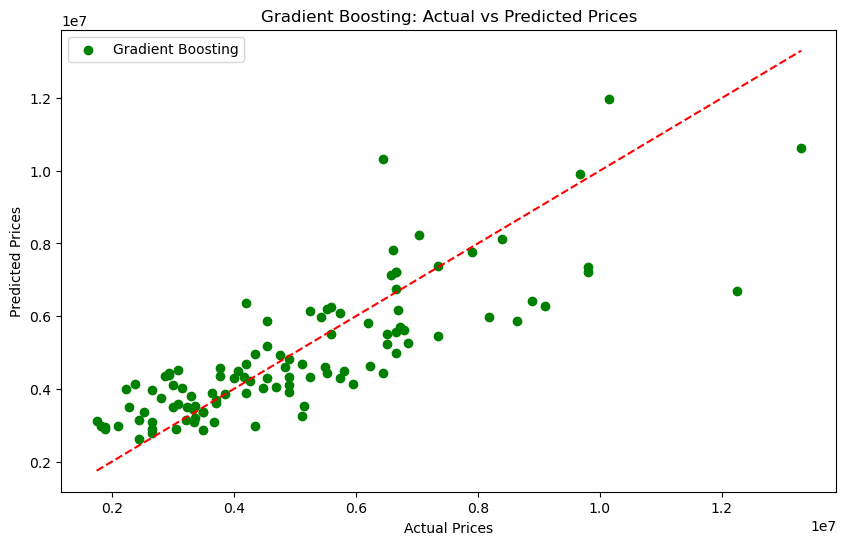

In [15]:
# Align the columns of X_train and X_test to ensure they are the same
X_train, X_test = X_train.align(X_test, join='left', axis=1)

# Now fit the Gradient Boosting model again
gb_regressor = GradientBoostingRegressor(random_state=42)
gb_regressor.fit(X_train, y_train)

# Predict using the Gradient Boosting model
y_pred_gb = gb_regressor.predict(X_test)

# Plot Predicted vs Actual Prices for Gradient Boosting
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_gb, color='green', label='Gradient Boosting')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Gradient Boosting: Actual vs Predicted Prices')
plt.legend()
plt.show()